# New Feature Analysis

**Objective:** Assess the impact of the new GL suggestion feature (deployed Oct 14th) on accuracy and user performance.

### Key Steps:
1.  **Data Prep:** Loading transaction logs and standardizing date formats.
2.  **Metric Calculation:** Computing "Success Rate" deltas (Before vs. After).
3.  **Insight Generation:** Statistical analysis using Pareto and Correlation charts to evaluate systemic lift.


<br>

## 1. Data Loading & Preparation

In this initial step, I'll set up the environment and ingest the raw data files:
* **Imports:** Loading necessary libraries (`pandas`, `logging`, `matplotlib`, `seaborn`).
* **Data Ingestion:** Reading the detailed transaction logs and summary reports into pandas DataFrames.
* **Logging:** Configuring the logging format to track the execution flow.

In [30]:
import pandas as pd
import logging
import os

# 1. Configure Logging
# This sets up the format to include time, level (INFO/ERROR), and the message
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

def load_data(detailed_filename, summary_filename):
    """
    Function to load two CSV files and return two DataFrames.
    
    Parameters:
    detailed_filename (str): Path to the detailed transaction CSV.
    summary_filename (str): Path to the daily summary CSV.
    
    Returns:
    tuple: (df_detailed, df_summary) if successful, otherwise (None, None).
    """
    try:
        # Load the Detailed file
        df_detailed = pd.read_csv(detailed_filename)
        logging.info(f"Successfully loaded AI performance detail file")
        logging.info(f"Detailed Data Shape: {df_detailed.shape}") 
        
        # Load the Summary file
        df_summary = pd.read_csv(summary_filename)
        logging.info(f"Successfully loaded AI performance summary file")
        logging.info(f"Summary Data Shape: {df_summary.shape}")
        
        return df_detailed, df_summary

    except FileNotFoundError as e:
        logging.error(f"File not found error: {e}")
        return None, None
    except Exception as e:
        logging.error(f"An unexpected error occurred: {e}")
        return None, None

# --- Main Execution ---

detailed_file = 'Example data - AI performance detail.csv' 
summary_file = 'Example data - AI performance summary.csv'        

# Run the function
df_detailed, df_summary = load_data(detailed_file, summary_file)

# Basic check inside the notebook (only if data loaded correctly)
if df_detailed is not None:
    logging.info("Displaying first 5 rows of detailed data...")
    display(df_detailed.head())

2025-12-10 16:15:07 - INFO - Successfully loaded AI performance detail file
2025-12-10 16:15:07 - INFO - Detailed Data Shape: (6441, 6)
2025-12-10 16:15:07 - INFO - Successfully loaded AI performance summary file
2025-12-10 16:15:07 - INFO - Summary Data Shape: (330, 6)
2025-12-10 16:15:07 - INFO - Displaying first 5 rows of detailed data...


,customer_id,invoice_id,invoice_date,vendor_id,Suggested gl account,Actual gl account
0,CUST_001,CUST_001_INV_1661,12/10/2025,V_229,CUST_001_GL_003,CUST_001_GL_003
1,CUST_001,CUST_001_INV_2126,12/10/2025,V_293,CUST_001_GL_002,CUST_001_GL_002
2,CUST_001,CUST_001_INV_8638,12/10/2025,V_785,CUST_001_GL_003,CUST_001_GL_005
3,CUST_001,CUST_001_INV_8330,12/10/2025,V_561,NaN,CUST_001_GL_002
4,CUST_001,CUST_001_INV_9175,12/10/2025,V_909,CUST_001_GL_001,CUST_001_GL_001


In [31]:
display(df_summary.head())

,Customer ID,Date,Count of GL lines,Count of correct GL suggestions,Count of wrong GL suggestions,Count of GL lines without suggestion
0,CUST_001,12/10/2025,6,3.0,2.0,1.0
1,CUST_001,13/10/2025,15,7.0,4.0,4.0
2,CUST_001,14/10/2025,11,4.0,6.0,1.0
3,CUST_001,15/10/2025,30,22.0,4.0,4.0
4,CUST_001,16/10/2025,23,15.0,2.0,6.0


## 2. Success Rate & Improvement Calculation

In this section, I'm processing the raw data to derive actionable insights:
* **Success Rate:** Calculated as `(Correct Suggestions / Total Lines) * 100` for each customer in both periods.
* **Improvement Delta:** Defined as `Rate(After) - Rate(Before)`. A positive value indicates performance gain, while a negative value indicates regression.
* **Sorting:** The resulting table is ranked by improvement magnitude to highlight the most significant changes.

In [32]:
%pip install Jinja2

Note: you may need to restart the kernel to use updated packages.


In [34]:
def calculate_success_rate(df):
    """
    Calculates success rate before and after Oct 14th based on GL suggestions.
    """
    # Column mapping based on your DataFrame structure
    col_date = 'Date'
    col_customer = 'Customer ID'
    col_correct = 'Count of correct GL suggestions'
    col_total = 'Count of GL lines' 

    try:
        logging.info("Starting success rate calculation...")

        # 1. Ensure date format is correct
        df[col_date] = pd.to_datetime(df[col_date], dayfirst=True)
        
        # 2. Define cutoff date
        cutoff_date = pd.to_datetime('2025-10-14')
        
        # 3. Classify periods
        df['period'] = df[col_date].apply(
            lambda x: 'Before 14/10' if x < cutoff_date else 'After 14/10'
        )
        
        # 4. Group by Customer and Period
        agg_df = df.groupby([col_customer, 'period'])[[
            col_correct, 
            col_total
        ]].sum().reset_index()

        # 5. Calculate success rate (Correct / Total * 100)
        agg_df['success_rate'] = (
            agg_df[col_correct] / agg_df[col_total]
        ) * 100
        
        logging.info("Aggregation completed successfully.")

        # 6. Pivot for final view
        final_view = agg_df.pivot(
            index=col_customer, 
            columns='period', 
            values='success_rate'
        )
        return final_view

    except Exception as e:
        logging.error(f"Calculation failed: {e}")
        return None

def color_improvement(val):
    if pd.isna(val):
        return ''
    color = 'green' if val > 0 else 'red'
    if val == 0:
        color = 'black'
        
    return f'color: {color}; font-weight: bold'

# --- Execute Analysis ---
if 'df_summary' in locals() and df_summary is not None:
    result_table = calculate_success_rate(df_summary)
    
    if result_table is not None:
        result_table['Improvement'] = result_table['After 14/10'] - result_table['Before 14/10']
        result_sorted = result_table.sort_values(by='Improvement', ascending=False)
        logging.info("Displaying success rate analysis:")
        try:
            styled_df = result_sorted.style\
                .map(color_improvement, subset=['Improvement'])\
                .format("{:.2f}%", na_rep="-")
        except AttributeError:
            styled_df = result_sorted.style\
                .applymap(color_improvement, subset=['Improvement'])\
                .format("{:.2f}%", na_rep="-")
            
        display(styled_df)   
    else:
        logging.warning("Analysis returned no results.")
else:
    logging.error("df_summary is not defined. Please run the data loading block first.")

2025-12-10 16:15:28 - INFO - Starting success rate calculation...
2025-12-10 16:15:28 - INFO - Aggregation completed successfully.
2025-12-10 16:15:28 - INFO - Displaying success rate analysis:


period,After 14/10,Before 14/10,Improvement
Customer ID,,,
CUST_033,81.68%,16.67%,65.01%
CUST_025,74.29%,20.00%,54.29%
CUST_007,71.60%,20.00%,51.60%
CUST_036,78.23%,27.78%,50.45%
CUST_029,84.75%,38.10%,46.65%
CUST_018,68.67%,23.81%,44.86%
CUST_023,72.80%,28.57%,44.23%
CUST_012,74.56%,32.00%,42.56%
CUST_047,80.53%,38.46%,42.07%


In [35]:
# Calculate Mean and Standard Deviation
mean_improvement = result_sorted['Improvement'].mean()
std_improvement = result_sorted['Improvement'].std()

# Display results
print(f"Average Improvement (Mean): {mean_improvement:.2f}%")
print(f"Standard Deviation: {std_improvement:.2f}%")

Average Improvement (Mean): 33.42%
Standard Deviation: 18.43%


## 3. Statistical Analysis & Visualization

In this final section, I'll use visual tools to interpret the results and derive strategic insights:

* **Impact Overview:** Comparing "Before" vs. "After" performance to visualize the overall lift.
* **Pareto Analysis:** Testing whether the improvement is driven by a few key accounts or distributed across the board.
* **Correlation Check:** Analyzing the relationship between a customer's starting point and their improvement magnitude (testing the "Gap Closing" hypothesis).

### A. Impact Overview: Before vs. After & Top Improvers
Generating a scatter plot to visualize the overall shift, alongside a bar chart highlighting the customers with the most significant positive and negative changes.

C:\Users\alo12\AppData\Local\Temp\ipykernel_15188\1313180417.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


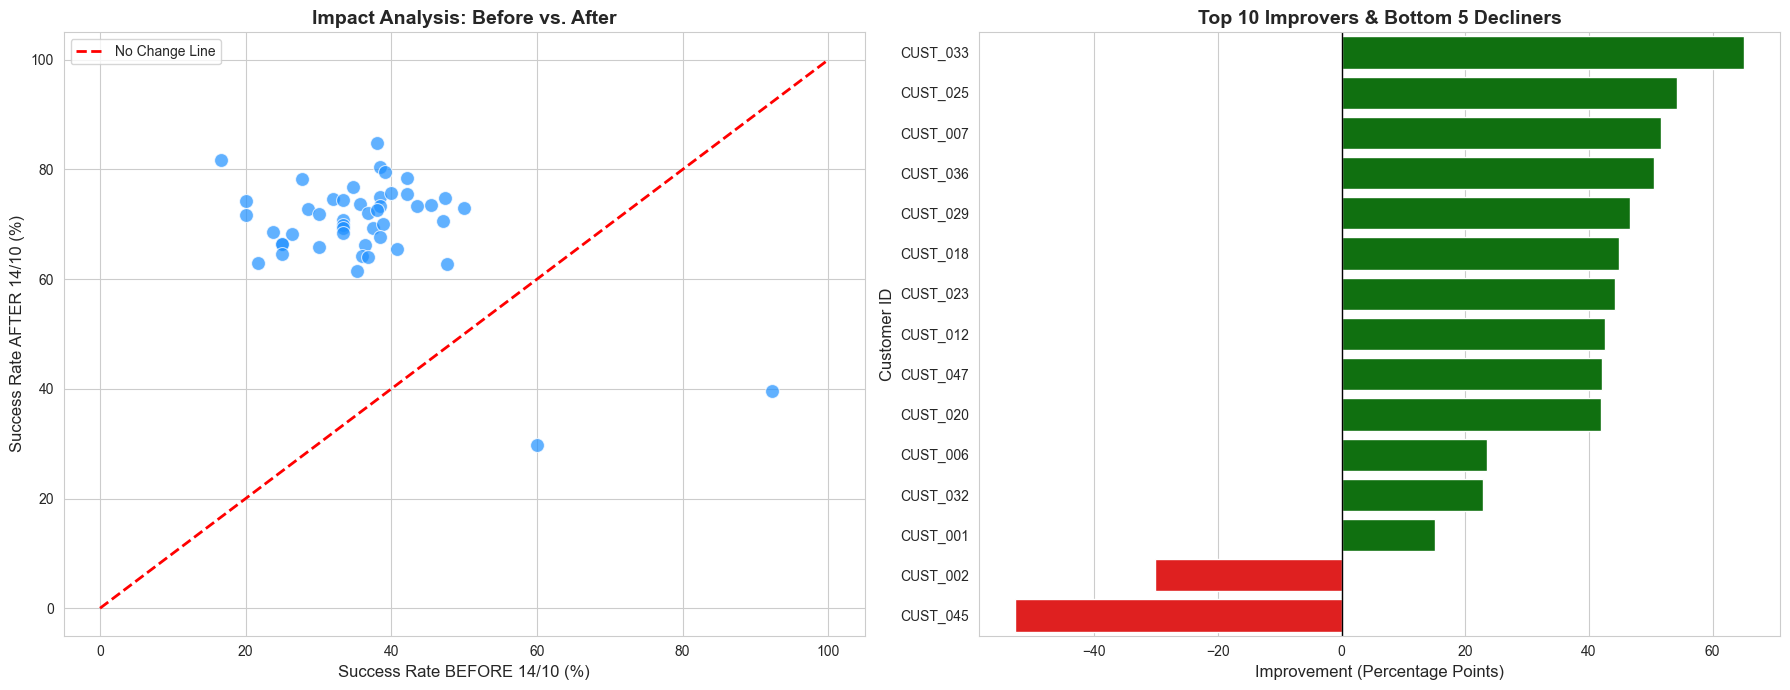

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_performance_analysis(df):
    if df is None or df.empty:
        print("No data available to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Graph 1: Scatter Plot (Before vs. After) ---
    sns.scatterplot(
        data=df, 
        x='Before 14/10', 
        y='After 14/10', 
        ax=axes[0],
        s=100,             
        color='dodgerblue',
        alpha=0.7          # Transparency
    )
    
    # Adding the "equality line" (where before = after)
    limit = 100
    axes[0].plot([0, limit], [0, limit], ls='--', c='red', linewidth=2, label='No Change Line')
    
    axes[0].set_title('Impact Analysis: Before vs. After', fontsize=14, weight='bold')
    axes[0].set_xlabel('Success Rate BEFORE 14/10 (%)', fontsize=12)
    axes[0].set_ylabel('Success Rate AFTER 14/10 (%)', fontsize=12)
    axes[0].legend()

    # --- Graph 2: Top Improvers and Decliners (Top 10 & Bottom 5) ---
    # Taking the top 10 (most improvement) and bottom 5 (most decline)
    top_10 = df.head(10)
    bottom_5 = df.tail(5)
    
    # Combining them into one graph
    subset = pd.concat([top_10, bottom_5])
    colors = ['green' if x >= 0 else 'red' for x in subset['Improvement']]
    
    sns.barplot(
        data=subset,
        x='Improvement',
        y=subset.index, # Customer ID
        ax=axes[1],
        palette=colors
    )
    
    axes[1].set_title('Top 10 Improvers & Bottom 5 Decliners', fontsize=14, weight='bold')
    axes[1].set_xlabel('Improvement (Percentage Points)', fontsize=12)
    axes[1].set_ylabel('Customer ID', fontsize=12)
    
    # Adding zero line
    axes[1].axvline(0, color='black', linewidth=1)

    plt.tight_layout()
    plt.show()

# --- Execute Plotting ---
if 'result_sorted' in locals() and result_sorted is not None:
    plot_performance_analysis(result_sorted)
else:
    print("Please run the previous calculation block to generate 'result_sorted' first.")

### Key Insights:
* **Systemic Lift (Left Chart):** The scatter plot reveals a widespread positive impact. The vast majority of customers (points above the red dashed line) achieved a higher success rate after the update.
* **Magnitude of Improvement (Right Chart):** The bar chart highlights the "big winners." The top improving customers saw a dramatic boost of **40-60%**, significantly outweighing the few isolated cases of regression.

<br>

### B. Pareto Analysis: Distribution of Improvement
Using the Pareto principle to visualize how the total improvement is distributed among customers.
This chart combines a **bar plot** (individual improvement) with a **line graph** (cumulative %) to reveal if the success is concentrated in a few key accounts (the "80/20 rule") or distributed broadly across the entire base.

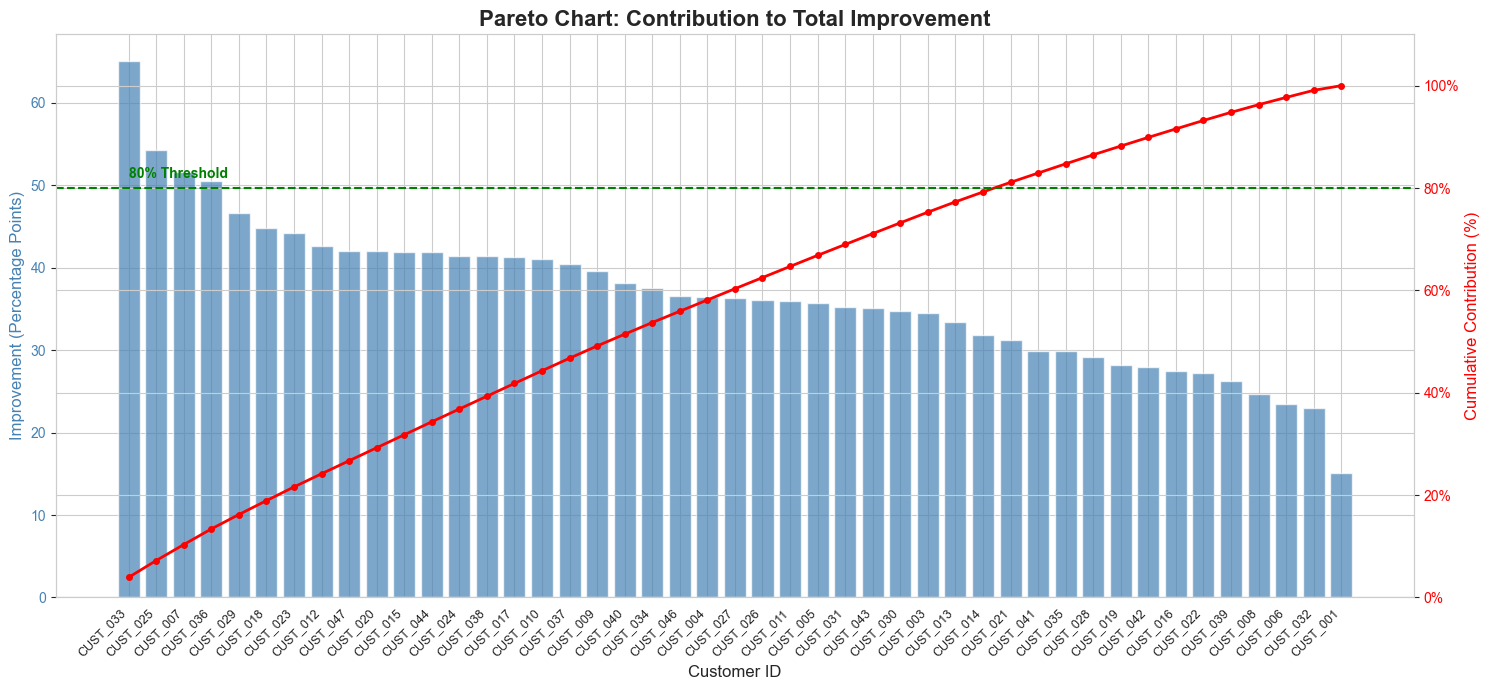

--- Pareto Insight ---
Top 32 customers account for roughly 80% of the total improvement points.
This represents 71.1% of the improving customers.
VERDICT: The improvement is distributed more evenly across customers (No strong 80/20 skew).


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def plot_pareto_improvement(df):
    pareto_df = df[df['Improvement'] > 0].copy()
    
    total_improvement_points = pareto_df['Improvement'].sum()
    pareto_df['cumulative_percentage'] = (pareto_df['Improvement'].cumsum() / total_improvement_points) * 100
    
    if pareto_df.empty:
        print("No positive improvements found to plot.")
        return

    # 3. Creating the graph
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # ---Y-axis: Improvement columns ---
    ax1.bar(pareto_df.index, pareto_df['Improvement'], color='steelblue', alpha=0.7, label='Improvement Magnitude')
    ax1.set_ylabel('Improvement (Percentage Points)', color='steelblue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    plt.xticks(rotation=45, ha='right', fontsize=9)
    ax1.set_xlabel('Customer ID', fontsize=12)

    ax2 = ax1.twinx()
    ax2.plot(pareto_df.index, pareto_df['cumulative_percentage'], color='red', marker='o', ms=4, linewidth=2, label='Cumulative %')
    ax2.set_ylabel('Cumulative Contribution (%)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 110) 
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

    # --- Helper lines (80/20 rule) ---
    ax2.axhline(80, color='green', linestyle='--', linewidth=1.5)
    ax2.text(0, 82, '80% Threshold', color='green', fontweight='bold')

    # Headline and layout
    plt.title('Pareto Chart: Contribution to Total Improvement', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()

    #--- Print verbal insight ---
    customers_80_percent = pareto_df[pareto_df['cumulative_percentage'] <= 80].shape[0]
    total_improvers = pareto_df.shape[0]
    ratio = (customers_80_percent / total_improvers) * 100
    
    print(f"--- Pareto Insight ---")
    print(f"Top {customers_80_percent} customers account for roughly 80% of the total improvement points.")
    print(f"This represents {ratio:.1f}% of the improving customers.")
    if ratio < 30:
        print("VERDICT: The Pareto Principle holds! A small group drives most of the improvement.")
    else:
        print("VERDICT: The improvement is distributed more evenly across customers (No strong 80/20 skew).")

# --- Execute Plotting ---
if 'result_sorted' in locals() and result_sorted is not None:
    plot_pareto_improvement(result_sorted)

### Key Insights:
* **Broad-Based Success:** The cumulative improvement line rises steadily (linearly) rather than sharply. This indicates that the classic **"80/20 rule" does not apply** here; the success is not concentrated in just a few accounts.
* **Systemic Robustness:** Instead of relying on a few "star" customers to drive the metrics, the feature provides value across nearly the entire customer base. Roughly **75% of customers** contribute to the first 80% of total improvement, proving the solution is robust and applicable to a wide variety of users.

<br>

### C. Correlation Analysis: Baseline vs. Improvement Magnitude
Finally, I examine the relationship between a customer's starting point and their improvement.
By plotting **Baseline Performance** (x-axis) against **Improvement Magnitude** (y-axis), I'm testing the "Gap Closing" hypothesis: Did the feature specifically target and resolve issues for low-performing customers?

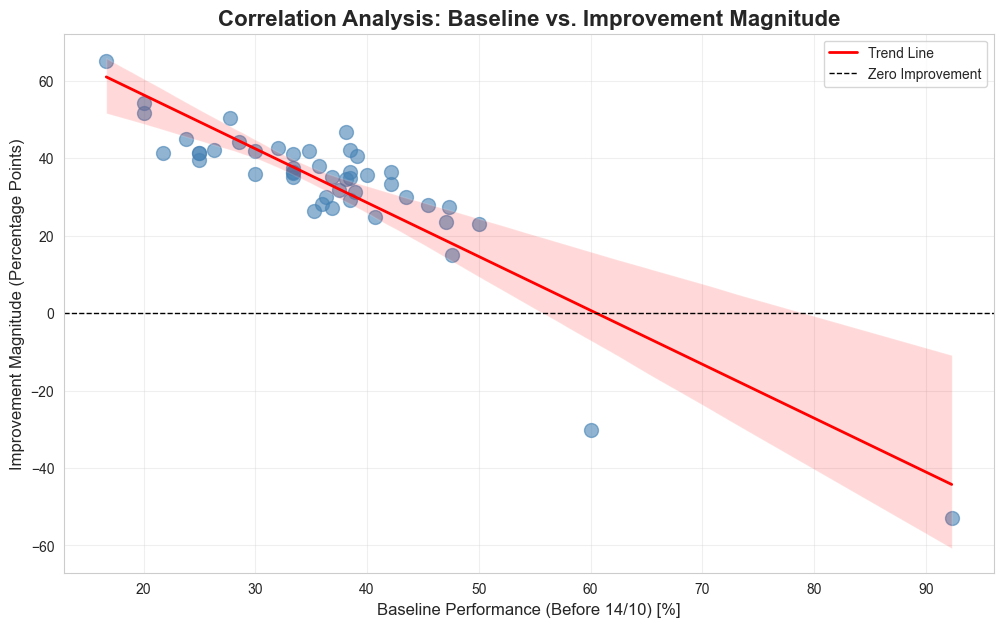

--- Statistical Insight ---
Correlation Coefficient: -0.90
Verdict: Strong Negative Correlation. The feature significantly helps 'weaker' customers catch up.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def plot_improvement_vs_baseline(df):
    if df is None or df.empty:
        print("No data available.")
        return

    plt.figure(figsize=(12, 7))

    clean_df = df.dropna(subset=['Before 14/10', 'Improvement'])
    
    sns.regplot(
        data=clean_df,
        x='Before 14/10',
        y='Improvement',
        scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 2, 'label': 'Trend Line'}
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Improvement')

    # Headlines
    plt.title('Correlation Analysis: Baseline vs. Improvement Magnitude', fontsize=16, weight='bold')
    plt.xlabel('Baseline Performance (Before 14/10) [%]', fontsize=12)
    plt.ylabel('Improvement Magnitude (Percentage Points)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

    # --- Statistical Analysis ---
    correlation = clean_df['Before 14/10'].corr(clean_df['Improvement'])
    print(f"--- Statistical Insight ---")
    print(f"Correlation Coefficient: {correlation:.2f}")
    
    if correlation < -0.5:
        print("Verdict: Strong Negative Correlation. The feature significantly helps 'weaker' customers catch up.")
    elif correlation > 0.5:
        print("Verdict: Positive Correlation. The feature mainly benefits customers who were already performing well.")
    else:
        print("Verdict: Moderate/No Correlation. The improvement is distributed, not strongly dependent on starting point.")

# --- Execute Plotting ---
if 'result_sorted' in locals() and result_sorted is not None:
    plot_improvement_vs_baseline(result_sorted)

### Key Insights:
* **The "Equalizer" Effect:** The strong negative correlation (downward slope) confirms my hypothesis. The feature acted as a powerful "equalizer," providing the most dramatic lift to customers who were previously struggling (low baseline).
* **Outlier Alert:** While the general trend is positive, the two data points in the bottom-right quadrant (high baseline but negative improvement) highlight specific cases where the new model underperformed compared to the old one.

<br>

## Appendix: Model Aggressiveness & Risk Profile Analysis

### How to Interpret the Chart
* **Decrease in Gray (Abstention):** Indicates that the model is more decisive and covers a larger portion of the data (Increased Coverage).
* **Red (Error) Trends:**
    * If the Gray area shrinks while the **Red area expands**, the model is **too aggressive** (converting uncertainty into errors).
    * If the Gray area shrinks while the **Red area shrinks (or remains stable)**, the model has successfully **learned** to solve complex edge cases that were previously ignored.

Columns in dataset: ['customer_id', 'invoice_id', 'invoice_date', 'vendor_id', 'Suggested gl account', 'Actual gl account']


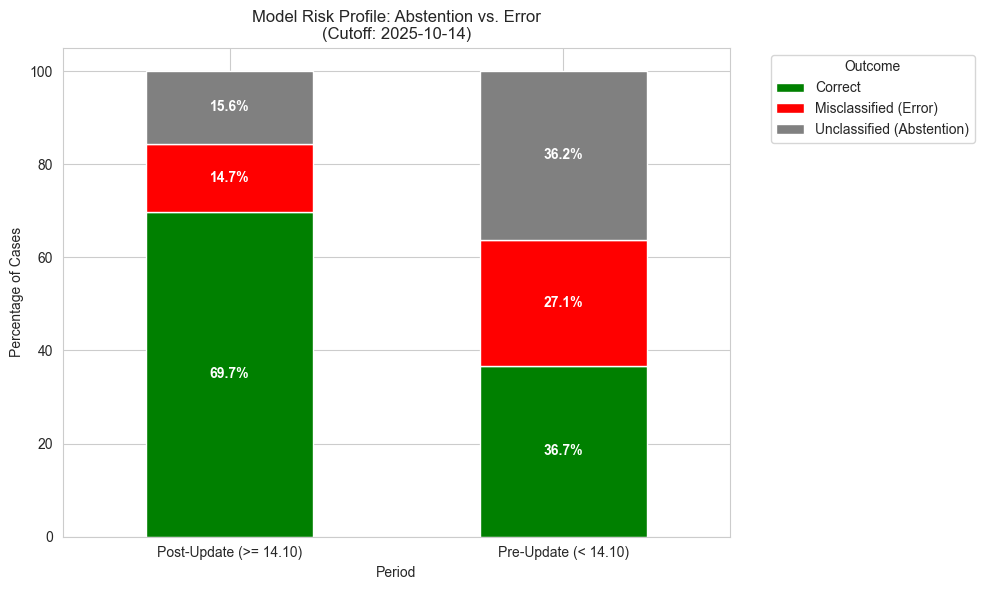


--- Data Check ---
Period
Post-Update (>= 14.10)    5637
Pre-Update (< 14.10)       804
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRED_COL = 'Suggested gl account'  
ACTUAL_COL = 'Actual gl account'   
DATE_COL = 'invoice_date'          
CUTOFF_DATE = '2025-10-14'       

if 'df_detailed' in locals() and df_detailed is not None:
    df_analysis = df_detailed.copy()
else:
    print("Warning: 'df_detailed' not found, trying to use 'df'...")
    df_analysis = df.copy() 

print(f"Columns in dataset: {df_analysis.columns.tolist()}")

df_analysis[DATE_COL] = pd.to_datetime(df_analysis[DATE_COL], dayfirst=True)

df_analysis = df_analysis.dropna(subset=[DATE_COL])

df_analysis['Period'] = np.where(
    df_analysis[DATE_COL] < pd.to_datetime(CUTOFF_DATE), 
    'Pre-Update (< 14.10)', 
    'Post-Update (>= 14.10)'
)

def analyze_outcome(row):
    pred = row[PRED_COL]
    actual = row[ACTUAL_COL]
    
    if pd.isna(pred) or str(pred).strip() == '' or str(pred).lower() == 'nan':
        return 'Unclassified (Abstention)'
    
    elif str(pred).strip() != str(actual).strip():
        return 'Misclassified (Error)'
    
    else:
        return 'Correct'

df_analysis['Outcome'] = df_analysis.apply(analyze_outcome, axis=1)

outcome_counts = df_analysis.groupby(['Period', 'Outcome']).size().unstack(fill_value=0)
outcome_ratios = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

colors_map = {
    'Correct': 'green', 
    'Misclassified (Error)': 'red', 
    'Unclassified (Abstention)': 'gray'
}
cols_in_data = [c for c in ['Correct', 'Misclassified (Error)', 'Unclassified (Abstention)'] if c in outcome_ratios.columns]
outcome_ratios = outcome_ratios[cols_in_data]
current_colors = [colors_map[c] for c in cols_in_data]

ax = outcome_ratios.plot(kind='bar', stacked=True, color=current_colors, figsize=(10, 6))

plt.title(f'Model Risk Profile: Abstention vs. Error\n(Cutoff: {CUTOFF_DATE})')
plt.ylabel('Percentage of Cases')
plt.xlabel('Period')
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

print("\n--- Data Check ---")
print(df_analysis['Period'].value_counts())

### Conclusion
The analysis refutes the concern of overconfidence.
Despite a sharp decrease in the **Abstention Rate** (Gray), the **Error Rate** (Red) has also decreased. This confirms that the model is successfully converting previously ambiguous cases into correct predictions, rather than generating noise.